In [2]:
import sys, os
project_root = r"C:/Users/Asia/Desktop/mocadr/MoviesRecommendations"
sys.path.insert(0, project_root)

from modules.train import train
from modules.predict import predict
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

df_true = pd.read_csv("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test_with_ratings.csv")

In [ ]:
Z_nmf, u_nmf, m_nmf, rmse_nmf = train("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/ratings.csv", "NMF")

preds_nmf = predict(
    "C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test.csv",
    {"Z_approx": Z_nmf, "user_map": u_nmf, "movie_map": m_nmf}
)

mse_nmf = mean_squared_error(df_true["rating"], preds_nmf["rating"])
test_rmse_nmf = np.sqrt(mse_nmf)

print(f"RMSE: {test_rmse_nmf:.4f}")

plt.plot(rmse_nmf.keys(), rmse_nmf.values())

plt.xlabel("r")
plt.ylabel("RMSE")
plt.title("RMSE vs. rank r for NMF")

plt.show()

Output()

Best r=36 with RMSE = 0.9749


In [4]:
Z_nmf_v2, u_nmf_v2, m_nmf_v2, rmse_nmf_v2 = train("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/ratings.csv", "NMF_V2")

preds_nmf_v2 = predict(
    "C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test.csv",
    {"Z_approx": Z_nmf_v2, "user_map": u_nmf_v2, "movie_map": m_nmf_v2}
)

mse_nmf_v2 = mean_squared_error(df_true["rating"], preds_nmf_v2["rating"])
test_rmse_nmf_v2 = np.sqrt(mse_nmf_v2)

print(f"RMSE: {test_rmse_nmf_v2:.4f}")

plt.plot(rmse_nmf_v2.keys(), rmse_nmf_v2.values())

plt.xlabel("r")
plt.ylabel("RMSE")
plt.title("RMSE vs. rank r for NMF_V2")

plt.show()

Output()

InvalidParameterError: The 'n_components' parameter of NMF must be an int in the range [1, inf), None or a str among {'auto'}. Got 3.5 instead.

Output()

Best r=1 and lambda=0.6 with RMSE = 0.9043
RMSE: 0.8000


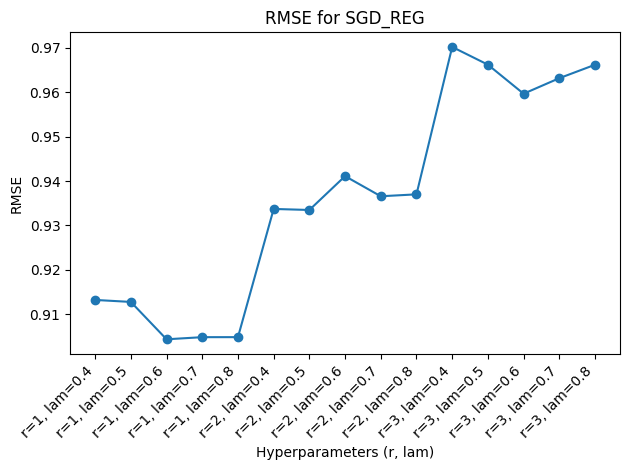

In [3]:
Z_SGD_reg, u_SGD_reg, m_SGD_reg, rmse_SGD_reg = train("C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/ratings.csv", "SGD_REG")

preds_SGD_reg = predict(
    "C:/Users/Asia/Desktop/mocadr/MoviesRecommendations/data/sample_test.csv",
    {"Z_approx": Z_SGD_reg, "user_map": u_SGD_reg, "movie_map": m_SGD_reg}
)

mse_SGD_reg = mean_squared_error(df_true["rating"], preds_SGD_reg["rating"])
test_rmse_SGD_reg = np.sqrt(mse_SGD_reg)

print(f"RMSE: {test_rmse_SGD_reg:.4f}")

x_labels = [f"r={i[0]}, lam={i[1]}" for i in rmse_SGD_reg.keys()]
y_values = list(rmse_SGD_reg.values())

plt.plot(x_labels, y_values, marker='o')
plt.xlabel("r, lambda")
plt.ylabel("RMSE")
plt.title("RMSE for SGD_REG")
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.tight_layout()
plt.show()

In [ ]:
# type of mask = Z > 0